>>> Processing files...
   -> Loaded Results_Pareto_1_100pct.xlsx | Cost: 2383.2 | Emi: 6953.1 | Total Water: 4954.6 MMGal
   -> Loaded Results_Pareto_1_90pct.xlsx | Cost: 2416.6 | Emi: 6300.0 | Total Water: 4642.2 MMGal
   -> Loaded Results_Pareto_2_80pct.xlsx | Cost: 2486.5 | Emi: 5600.0 | Total Water: 4248.4 MMGal
   -> Loaded Results_Pareto_3_60pct.xlsx | Cost: 2859.9 | Emi: 4200.0 | Total Water: 4373.4 MMGal
   -> Loaded Results_Pareto_4_50pct.xlsx | Cost: 5130.1 | Emi: 3500.0 | Total Water: 3268.5 MMGal


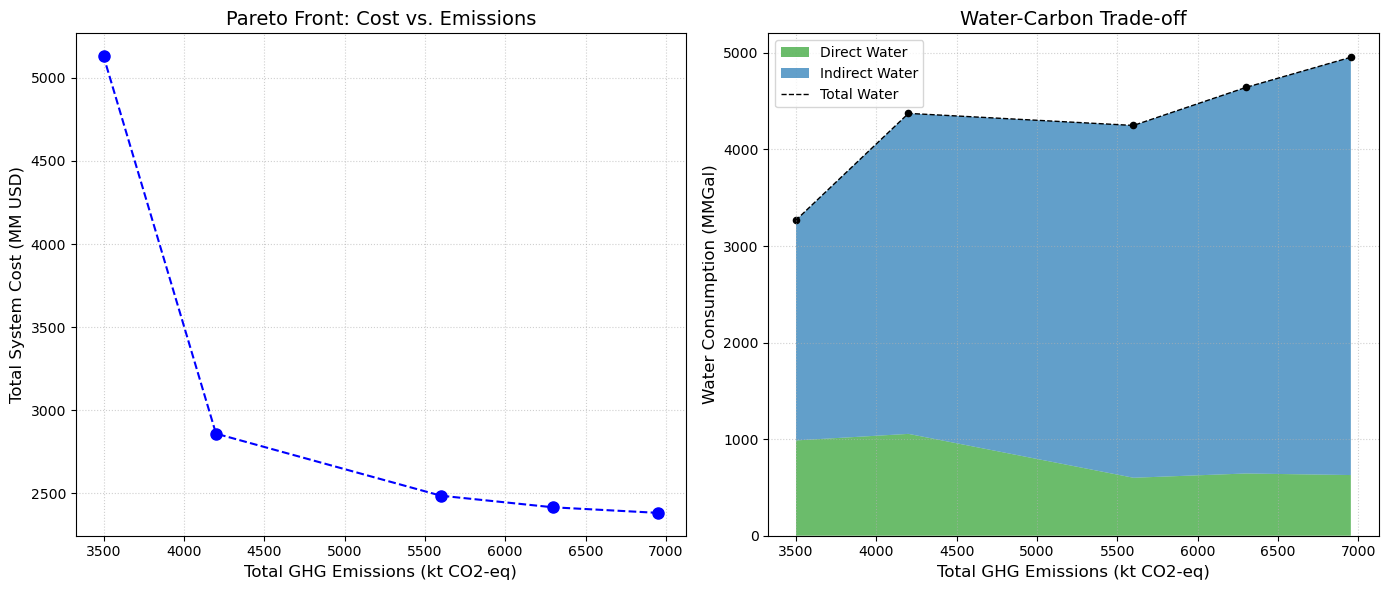

In [3]:
using DataFrames, XLSX, PyPlot, Statistics

# ==========================================
# 1. Configuration
# ==========================================
# Updated file names based on the VS Code explorer image
# Removed '%' from the labels as requested
files_info = [
    (1, "100", "Results_Pareto_1_100pct.xlsx"),
    (2, "90",  "Results_Pareto_1_90pct.xlsx"),
    (3, "80",  "Results_Pareto_2_80pct.xlsx"),
    (4, "60",  "Results_Pareto_3_60pct.xlsx"),
    (5, "50",  "Results_Pareto_4_50pct.xlsx"),
    # (6, "45",  "Results_Pareto_1_45pct.xlsx")
]

df_results = DataFrame(
    Label = String[], 
    Emissions = Float64[], 
    Cost = Float64[], 
    Water_Total = Float64[], 
    Water_Direct = Float64[], 
    Water_Indirect = Float64[]
)

println(">>> Processing files...")

# ==========================================
# 2. Data Extraction
# ==========================================
for (case_num, label, fname) in files_info
    if !isfile(fname)
        println("⚠️ Warning: File not found: $fname")
        continue
    end

    xf = XLSX.readxlsx(fname)

    # -------------------------------------------------------
    # A. EMISSIONS (Robust Method)
    # -------------------------------------------------------
    # We sum Cols 2, 3, and 4 to get Total Emissions (Man + Op + Dec).
    sh_emi = DataFrame(XLSX.gettable(xf["Emissions_summary"]))
    
    # Find "Total" row index
    total_row_idx = findfirst(x -> string(x) == "Total", sh_emi[!, 1])
    
    val_emi = 0.0
    if !isnothing(total_row_idx)
        val_emi = sh_emi[total_row_idx, 2] + sh_emi[total_row_idx, 3] + sh_emi[total_row_idx, 4]
    else
        # Fallback: Sum entire columns
        val_emi = sum(sh_emi[!, 2]) + sum(sh_emi[!, 3]) + sum(sh_emi[!, 4])
    end

    # -------------------------------------------------------
    # B. COSTS (Robust Method)
    # -------------------------------------------------------
    # We sum Cols 2, 3, 4, and 5 (Inv + FixOM + VarOM + Dec)
    sh_cost = DataFrame(XLSX.gettable(xf["Costs_summary"]))
    total_row_cost_idx = findfirst(x -> string(x) == "Total", sh_cost[!, 1])
    
    val_cost = 0.0
    if !isnothing(total_row_cost_idx)
        val_cost = sh_cost[total_row_cost_idx, 2] + 
                   sh_cost[total_row_cost_idx, 3] + 
                   sh_cost[total_row_cost_idx, 4] + 
                   sh_cost[total_row_cost_idx, 5]
    else
        val_cost = sum(sh_cost[!, 2]) + sum(sh_cost[!, 3]) + 
                   sum(sh_cost[!, 4]) + sum(sh_cost[!, 5])
    end

    # -------------------------------------------------------
    # C. WATER (Name Matching)
    # -------------------------------------------------------
    # Values in these files are already in MMGal thanks to the new Results.jl
    sh_water = DataFrame(XLSX.gettable(xf["Water_Consumption"]))
    
    # Helper to find column index by partial string match (handles new MMGal headers automatically)
    function get_col_sum(df, name_part)
        c = findfirst(n -> occursin(lowercase(name_part), lowercase(string(n))), names(df))
        return isnothing(c) ? 0.0 : sum(df[!, c])
    end

    val_indirect = get_col_sum(sh_water, "Grid_Indirect")
    
    direct_keywords = ["DC_Direct", "Cogen_Direct", "Boiler_Direct", "Nuclear_Direct", "Chillers_Direct"]
    val_direct = sum(get_col_sum(sh_water, k) for k in direct_keywords)
    
    push!(df_results, (label, val_emi, val_cost, val_direct + val_indirect, val_direct, val_indirect))
    println("   -> Loaded $fname | Cost: $(round(val_cost, digits=1)) | Emi: $(round(val_emi, digits=1)) | Total Water: $(round(val_direct + val_indirect, digits=1)) MMGal")
end

# Sort Descending (High Emission -> Low Emission)
sort!(df_results, :Emissions, rev=true)

# ==========================================
# 3. Plotting
# ==========================================
fig, (ax1, ax2) = PyPlot.subplots(1, 2, figsize=(14, 6))

# --- Plot 1: Pareto ---
ax1.plot(df_results.Emissions, df_results.Cost, marker="o", linestyle="--", color="b", markersize=8)
# for i in 1:nrow(df_results)
#     ax1.annotate(df_results.Label[i], 
#                  xy=(df_results.Emissions[i], df_results.Cost[i]), 
#                  xytext=(5, 5), textcoords="offset points", fontweight="bold")
# end
ax1.set_xlabel("Total GHG Emissions (kt CO2-eq)", fontsize=12)
ax1.set_ylabel("Total System Cost (MM USD)", fontsize=12)
ax1.set_title("Pareto Front: Cost vs. Emissions", fontsize=14)
ax1.grid(true, linestyle=":", alpha=0.6)

# --- Plot 2: Water Trade-off ---
ax2.stackplot(df_results.Emissions, df_results.Water_Direct, df_results.Water_Indirect, 
              labels=["Direct Water", "Indirect Water"], colors=["#2ca02c", "#1f77b4"], alpha=0.7)
ax2.plot(df_results.Emissions, df_results.Water_Total, color="k", linestyle="--", linewidth=1, label="Total Water")
ax2.scatter(df_results.Emissions, df_results.Water_Total, color="k", s=20)

# for i in 1:nrow(df_results)
#     ax2.annotate(df_results.Label[i], 
#                  xy=(df_results.Emissions[i], df_results.Water_Total[i]), 
#                  xytext=(0, 10), textcoords="offset points", ha="center")
# end
ax2.set_xlabel("Total GHG Emissions (kt CO2-eq)", fontsize=12)

# UPDATED: Y-axis label explicitly states MMGal
ax2.set_ylabel("Water Consumption (MMGal)", fontsize=12)
ax2.set_title("Water-Carbon Trade-off", fontsize=14)
ax2.legend(loc="upper left")
ax2.grid(true, linestyle=":", alpha=0.6)

PyPlot.tight_layout()
display(fig)